# Neural Network creation for Pump-valves block data

***

**Author:** Juan M. Montes-Sánchez

**GitHub:** https://github.com/juamonsan

***

In this notebook you will find a step by step guide where you will:
- Load data taken with FP-SNS-DATALOG1 on a STEVAL-MKSBOX1V1FP-SNS-DATALOG and pre-processed as .csv files with "Dataset preparation" notebook from this same project
- Split the data into train, evaluation and test
- Generate and train a Neural Network capable of classifing lectures from the sensors
- Generating plots and metrics related to the data or the Neural Network

## Requirements

You **MUST** have:
- Data in .csv and with a proper folder structure created with "Dataset preparation" notebook from this same project

Optional requirements include:
- CUDA compatible Nvidia GPU

## Previous steps

### Neural Network environment: Importing Keras/Tensorflow

Import tensorflow and check if we have GPUs availables. If so, it means a GPU is ready to be used for tensorflow training.

In [1]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

import sys

print("Python version {}.{}".format(sys.version_info.major, sys.version_info.minor))

print("Tensorflow version " + tf.__version__)

Python version 3.7
Tensorflow version 2.1.0


In [2]:
from tensorflow.python.client import device_lib

num_GPUs=len(tf.config.experimental.list_physical_devices('GPU'))

tf.config.list_physical_devices('GPU')

device_lib.list_local_devices()

tf.test.is_built_with_cuda()

tf.debugging.set_log_device_placement(True)


if(num_GPUs>0):
    print("Your system has {} GPUs availables".format(num_GPUs))
else:
    print("No GPUs available")    


Your system has 1 GPUs availables


---
If we have a Nvidia GPU with drivers and CUDA properly installed we can also get some extra information: GPU model, driver and CUDA versions, activity...

In [3]:
# GPU count and name
!nvidia-smi -L
# GPU activity
!nvidia-smi

GPU 0: NVIDIA GeForce GTX 1650 (UUID: GPU-235cadad-b6ee-9e16-4bcd-63bcc7b79e19)
Wed Jun 21 12:08:05 2023       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.98                 Driver Version: 535.98       CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  | 00000000:01:00.0 Off |                  N/A |
| N/A   48C    P8               3W /  50W |    158MiB /  4096MiB |      0%      Default |
|                                         |                      |            

---
### Other imports

In [8]:
# More imports
import matplotlib.pyplot as plt #for plotting raw data
import os #for system folders and files management
import pathlib #for system folders and files management
import pandas as pd #for Dataframe handling

import numpy as np
import math
import csv

from IPython.display import Audio #for WAV generation

# End

In [5]:
# Make numpy values easier to read.
np.set_printoptions(precision=3, suppress=True)

### Definitions

In [15]:
# Dando la ruta del fichero CSV, muestra una grafica de los datos
def plot_record(file_path, xName, yName):
    data = pd.read_csv(file_path, sep=',')
    data = data.to_numpy()
    print("Shape of the data is: {}".format(np.shape(data)))
    #plt.plot(data[:,0], data[:,1], #if we have a timestamp at column 0
    #         data[:,0], data[:,2],
    #         data[:,0], data[:,3])
    plt.plot(range(np.shape(data)[0]), data[:,0],
             range(np.shape(data)[0]), data[:,1],
             range(np.shape(data)[0]), data[:,2])
    plt.xlabel(xName)
    plt.ylabel(yName)
    #plt.xlim((0, 200))
    #plt.ylim((-1500, 1500))

## Loading data

### Loading from CSV



Select data folder and extract data size from the content of the files. We are going to consider the data is already in the desired format.

Number of samples: 996
Sample size: 550
Number of features: 3
-----------------------
Plot example for first file:
-----------------------
The class for this file is 3
Shape of the data is: (549, 3)


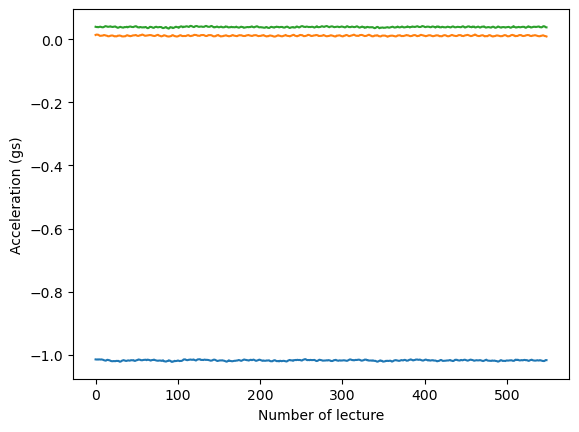

In [26]:
csv_folder_path="DATA\\expData\\STBOX_00002_Windows" #Select desired path
sensor_folder="ACC_LIS3DHH_1100Hz" #Select desired sensor folder

full_path=os.path.join(csv_folder_path,sensor_folder)

Current_file_path = os.path.join(full_path,os.listdir(full_path)[0])

Current_file = open(Current_file_path) # Open first file for counting rows

num_samples= len(os.listdir(full_path)) #number of .csv files in total
tam_samples= len(Current_file.readlines())#number of lectures in a window sample (rows in each .csv)
num_features = 3 #axis number (3 for accel) TODO: read column number from the file

print("Number of samples: {}\nSample size: {}\nNumber of features: {}".format(num_samples,tam_samples,num_features))
print("-----------------------\nPlot example for first file:\n-----------------------")

file_class=int(Current_file_path[-5]) # Class is in the filename, at the end, just before file extension
print("The class for this file is {}".format(file_class))

plot_record(Current_file_path, 'Number of lecture', 'Acceleration (gs)')

Current_file.close() # Close file

In [ ]:

trainX=np.empty([num_samples, tam_samples, num_features])

#### Downsample

Only in case we want to decrease the amount of data (simulating a lower frequency) we can run the next code:

In [ ]:
# para reducir la frecuencia se puede usar! TODO ajustar al ODR
# Slice [start:stop:step], starting from index 5 take every 110th record.-> 1100
df_sliced = df[5::110]
df_sliced.head()

#### Split the data

In [ ]:
# TODO Esto no se puede hacer así salvo que tengamos ya los archivos separados por clase, diría yo. Que con la prueba, no es el caso.

column_indices = {name: i for i, name in enumerate(dfs_windowed.columns)}

n = len(dfs_windowed)
train_df = dfs_windowed[0:int(n*0.7)]
val_df = dfs_windowed[int(n*0.7):int(n*0.9)]
test_df = dfs_windowed[int(n*0.9):]

num_features = dfs_windowed.shape[1]

# Normalization
#train_mean = train_df.mean()
#train_std = train_df.std()

#train_df = (train_df - train_mean) / train_std
#val_df = (val_df - train_mean) / train_std
#test_df = (test_df - train_mean) / train_std


#### Normalization - mean window

In [ ]:
#estoy hay que mirárselo...

class WindowGenerator():
  def __init__(self, input_width, label_width, shift,
               train_df=train_df, val_df=val_df, test_df=test_df,
               label_columns=None):
    # Store the raw data.
    self.train_df = train_df
    self.val_df = val_df
    self.test_df = test_df

    # Work out the label column indices.
    self.label_columns = label_columns
    if label_columns is not None:
      self.label_columns_indices = {name: i for i, name in
                                    enumerate(label_columns)}
    self.column_indices = {name: i for i, name in
                           enumerate(train_df.columns)}

    # Work out the window parameters.
    self.input_width = input_width
    self.label_width = label_width
    self.shift = shift

    self.total_window_size = input_width + shift

    self.input_slice = slice(0, input_width)
    self.input_indices = np.arange(self.total_window_size)[self.input_slice]

    self.label_start = self.total_window_size - self.label_width
    self.labels_slice = slice(self.label_start, None)
    self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

  def __repr__(self):
    return '\n'.join([
        f'Total window size: {self.total_window_size}',
        f'Input indices: {self.input_indices}',
        f'Label indices: {self.label_indices}',
        f'Label column name(s): {self.label_columns}'])


### Network definition

In [ ]:
#Copiado de notebook de Curro (definiciones de distintas RNN):

def create_1layer_lstm_model(nodes,drp):
    
    input_shape = (None, 64, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(LSTM((nodes)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model


def create_1layer_gru_model(nodes,drp):
    
    input_shape = (None, 64, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(GRU((nodes)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model


def create_2layer_lstm_model(nodes_1stl,nodes_2ndl,drp):
    
    input_shape = (None, 64, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(LSTM((nodes_1stl), return_sequences=True))
    rnn_model.add(Dropout(drp))
    rnn_model.add(LSTM((nodes_2ndl)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model


def create_2layer_gru_model(nodes_1stl,nodes_2ndl,drp):
    
    input_shape = (None, 64, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(GRU((nodes_1stl), return_sequences=True))
    rnn_model.add(Dropout(drp))
    rnn_model.add(GRU((nodes_2ndl)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model

In [ ]:
## class_names = ['NEW', 'OLD', 'STOP']
class_names = ['1', '2', '3']

model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])



---
## Data plot

### Metrics for raw data

This section contains code for getting metrics from raw data and generating plot images

In [ ]:
# TO DO: METRICS AND PLOT CODE

---
### Metrics for data converted to CSV
This section contains code for getting metrics from raw data and generating plot images

In [ ]:
# TO DO: METRICS AND PLOT CODE

In [ ]:
#fft = tf.signal.rfft(df['T (degC)'])

from scipy.fft import fftfreq 
#plt.style.use("seaborn")

t = df["Time"].loc[df["Time"] > 5].loc[df["Time"] < 10]
s = df["A_z [g]"].loc[df["Time"] > 5].loc[df["Time"] < 10]

fft = np.fft.fft(s)
fft[0] = 0
fftfreq = np.fft.fftfreq(len(s))*len(s)/(t.max()-t.min())

plt.subplot(1, 2, 1)
plt.xlabel("Frequency Domain")
plt.ylabel("Amplitude")
plt.plot(fftfreq, fft)
plt.subplot(1, 2, 2)
plt.plot(t, s)
plt.show()

